# Andmete eksploratiivne analüüs

## Impordid ja seadistused

In [2]:
import sys

import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Impordi tabelite ja graafikute joonistamiseks vajalikud funktsioonid
sys.path.append('..')
from Python.visuaalide_abilised import maara_raporti_stiil
from Python.visuaalide_abilised import sagedustabel, mitmikvastuse_sagedustabel, loo_risttabel, leia_sildi_mapping
from Python.visuaalide_abilised import loo_tulpdiagramm, loo_hor_tulpdiagramm, loo_stacked_tulpdiagramm, loo_hor_stacked_tulpdiagramm, loo_diverging_stacked_tulpdiagramm

## Graafikute seadistused

In [3]:
style = maara_raporti_stiil()

## Andmete import

In [4]:
# Impordi andmed puhastamise käigus loodud CVS-st
data = pd.read_csv('../data/cleaned_data.csv')
data

,Vastaja_ID,K1_aeg,K2_kontroll,K3_vanus,K4_sugu,K5_elukoht,K6_keel,K7_sorteerimiskaitumine,K8_teadmiste_hinnang,K9_probleemi_tosidus,...,K32_teabe_allikad_10,K32_teabe_allikad_muu_tekst,K33_julgustavad_tegurid_1,K33_julgustavad_tegurid_2,K33_julgustavad_tegurid_3,K33_julgustavad_tegurid_4,K33_julgustavad_tegurid_5,K33_julgustavad_tegurid_6,K33_julgustavad_tegurid_7,K33_julgustavad_tegurid_muu_tekst
0,1,2025-03-10 08:01:13,1,2,2,1,1,2,5,5,...,0,NaN,1,1,1,1,0,1,0,NaN
1,2,2025-03-10 16:55:18,1,2,2,9,1,3,3,3,...,0,NaN,1,1,0,0,0,0,0,NaN
2,3,2025-03-17 21:06:37,1,4,2,1,1,2,4,5,...,0,NaN,1,1,0,1,0,0,0,NaN
3,4,2025-03-17 20:00:21,1,4,2,16,1,3,2,5,...,0,NaN,1,0,0,0,0,0,0,NaN
4,5,2025-03-20 21:15:13,1,2,2,12,1,3,4,5,...,0,NaN,1,1,1,1,1,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,674,2025-03-28 16:34:49,1,4,2,9,1,2,2,5,...,0,NaN,1,1,0,0,1,0,0,NaN
664,675,2025-04-13 09:46:43,1,2,2,1,1,4,4,5,...,0,NaN,1,1,1,0,0,0,0,NaN
665,676,2025-04-15 13:31:30,1,4,2,1,1,3,3,5,...,0,NaN,1,1,1,0,1,0,0,NaN
666,677,2025-03-11 19:48:03,1,3,2,1,1,3,3,4,...,0,NaN,1,0,1,0,0,0,0,NaN


In [5]:
# Impordi vastuste koodid
koodid = pd.read_csv('../data/vastuste_koodid.csv')
koodid

,kysimus,kood,vastus,vastus_lyhike
0,K2_kontroll,1,Jah,Jah
1,K2_kontroll,2,Ei,Ei
2,K3_vanus,1,Alaealine (17 või noorem),<17
3,K3_vanus,2,18-29,18-29
4,K3_vanus,3,30-49,30-49
...,...,...,...,...
168,K43_roivaste_tellimine_proovimiseks,1,Ei ole seda kordagi teinud,NaN
169,K43_roivaste_tellimine_proovimiseks,2,2 - puudu,NaN
170,K43_roivaste_tellimine_proovimiseks,3,3 - puudu,NaN
171,K43_roivaste_tellimine_proovimiseks,4,4 - puudu,NaN


## Demograafilised näitajad

- Vanus
- Sugu
- Elukoht
- Keel

In [6]:
print(f'\nVastuste arv: {data['Vastaja_ID'].count()}')


Vastuste arv: 668


In [7]:
# Leia vastajate arv vanusegrupiti
vanus_sagedus = sagedustabel(data, koodid, 'K3_vanus')
vanus_sagedus

,kood,vastus_lyhike,vastuste_arv,protsent,protsent_str
2,1,<17,57,9,9%
3,2,18-29,124,19,19%
4,3,30-49,370,55,55%
5,4,50-64,104,16,16%
6,5,65>,13,2,2%


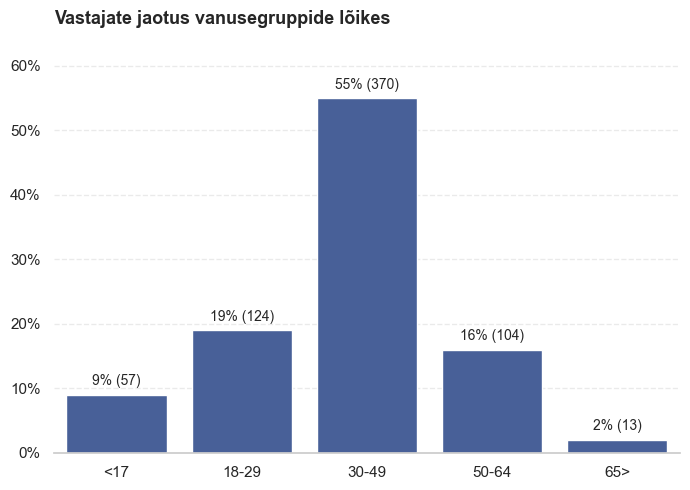

In [8]:
# Vanuse jaotuse tulpdiagramm
fig, ax = loo_tulpdiagramm(
    vanus_sagedus,
    'Vastajate jaotus vanusegruppide lõikes',
    style
)

plt.show()

In [9]:
# Leia vastajate arv soo alusel
sugu_sagedus = sagedustabel(data, koodid, 'K4_sugu')
sugu_sagedus

,kood,vastus_lyhike,vastuste_arv,protsent,protsent_str
7,1,Mees,71,11,11%
8,2,Naine,591,88,88%
9,3,Määratlemata,6,1,1%


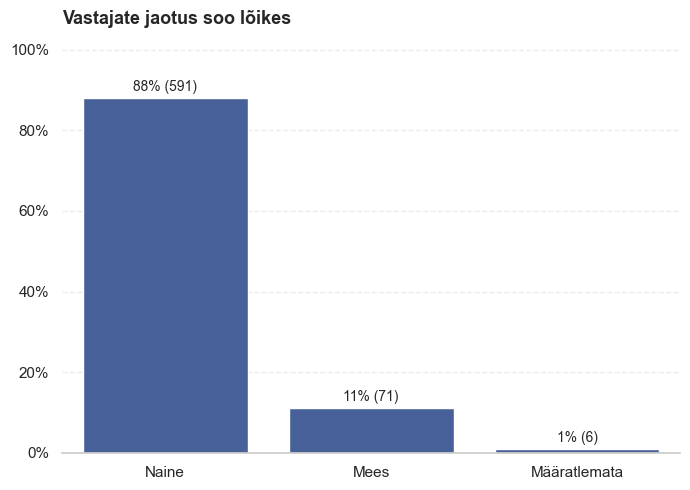

In [10]:
# Soo jaotuse tulpdiagramm
fig, ax = loo_tulpdiagramm(
    sugu_sagedus,
    'Vastajate jaotus soo lõikes',
    style,
    sort=True
)

plt.show()

In [11]:
# Leia vastajate arv elukoha alusel
elukoht_sagedus = sagedustabel(data, koodid, 'K5_elukoht')
elukoht_sagedus

,kood,vastus_lyhike,vastuste_arv,protsent,protsent_str
10,1,Harju,406,61,61%
11,2,Hiiu,2,0,0%
12,3,Ida-Viru,3,0,0%
13,4,Järva,35,5,5%
14,5,Jõgeva,7,1,1%
15,6,Lääne,1,0,0%
16,7,Lääne-Viru,12,2,2%
17,8,Põlva,6,1,1%
18,9,Pärnu,56,8,8%
19,10,Rapla,13,2,2%


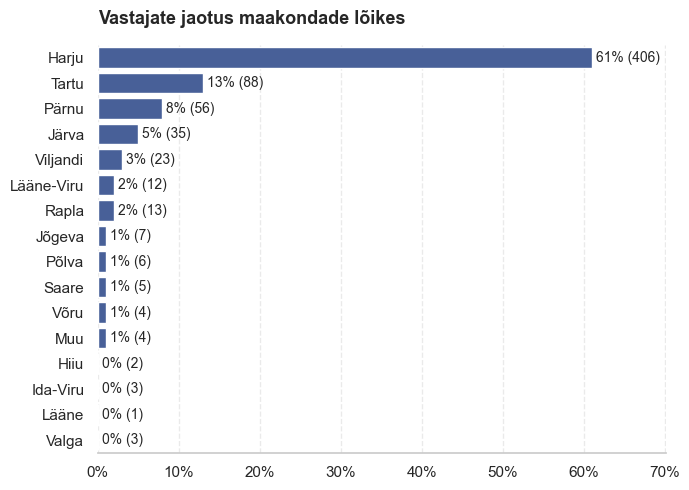

In [12]:
# Elukoha jaotuse tulpdiagramm
fig, ax = loo_hor_tulpdiagramm(
    elukoht_sagedus,
    'Vastajate jaotus maakondade lõikes',
    style,
    sort=True
)

plt.show()

In [13]:
# Leia vastajate arv keele alusel
keel_sagedus = sagedustabel(data, koodid, 'K6_keel')
keel_sagedus

,kood,vastus_lyhike,vastuste_arv,protsent,protsent_str
26,1,Eesti,641,96,96%
27,2,Inglise,7,1,1%
28,3,Vene,15,2,2%
29,4,Muu,5,1,1%


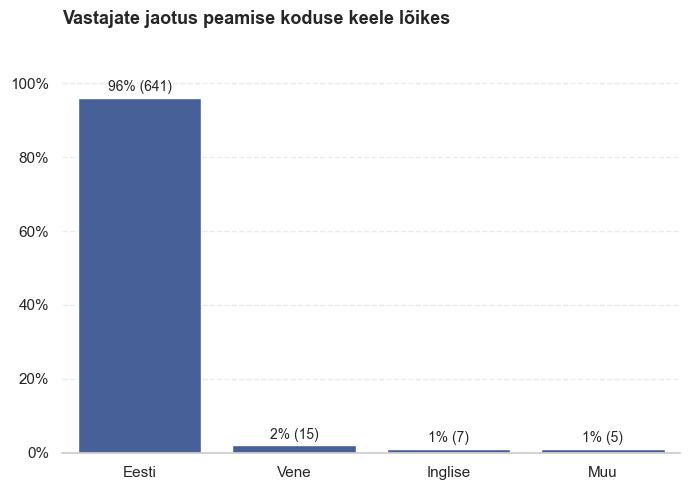

In [14]:
# Keele jaotuse tulpdiagramm
fig, ax = loo_tulpdiagramm(
    keel_sagedus,
    "Vastajate jaotus peamise koduse keele lõikes",
    style,
    sort=True
)

plt.show()

## Demograafiliste näitajate vahelised seosed

In [15]:
# Grupeeri maakonnad, kust vähe vastuseid variandi Muu alla
data_puhastatud = data.copy()
data_puhastatud['K5_elukoht'] = data['K5_elukoht'].replace([2, 3, 5, 6, 7, 8, 10, 11, 13, 15], 16)

In [16]:
# Vanuseline jaotus elukoha alusel
vanus_elukoht = loo_risttabel(data_puhastatud, koodid, 'K5_elukoht', 'K3_vanus')
vanus_elukoht

K3_vanus,<17,18-29,30-49,50-64,65>
K5_elukoht,,,,,
Harju,22,81,236,56,11
Järva,26,5,2,2,0
Pärnu,0,8,36,12,0
Tartu,4,19,52,12,1
Viljandi,0,3,15,5,0
Muu,5,8,29,17,1


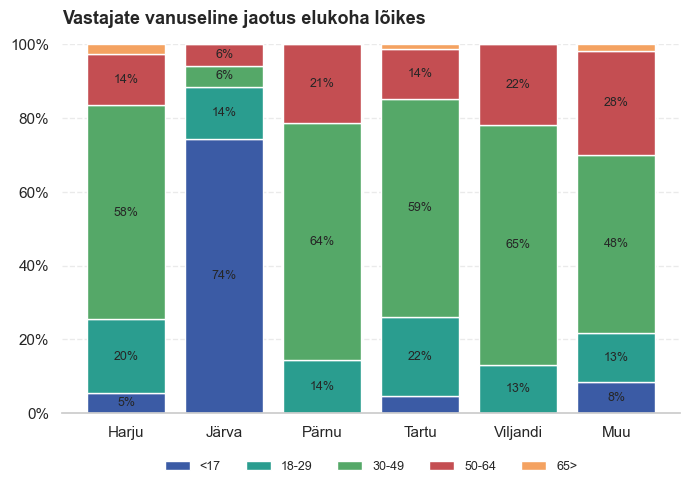

In [17]:
# Vanuseline jaotus elukoha alusel - diagramm
loo_stacked_tulpdiagramm(
    vanus_elukoht,
    'Vastajate vanuseline jaotus elukoha lõikes',
    style
)

plt.show()

In [18]:
# Soo jaotus elukoha alusel
sugu_elukoht = loo_risttabel(data, koodid, 'K5_elukoht', 'K4_sugu')

sugu_elukoht

K4_sugu,Mees,Naine,Määratlemata
K5_elukoht,,,
Harju,40,363,3
Hiiu,0,2,0
Ida-Viru,0,3,0
Järva,17,17,1
Jõgeva,1,6,0
Lääne,0,1,0
Lääne-Viru,1,11,0
Põlva,1,5,0
Pärnu,8,48,0


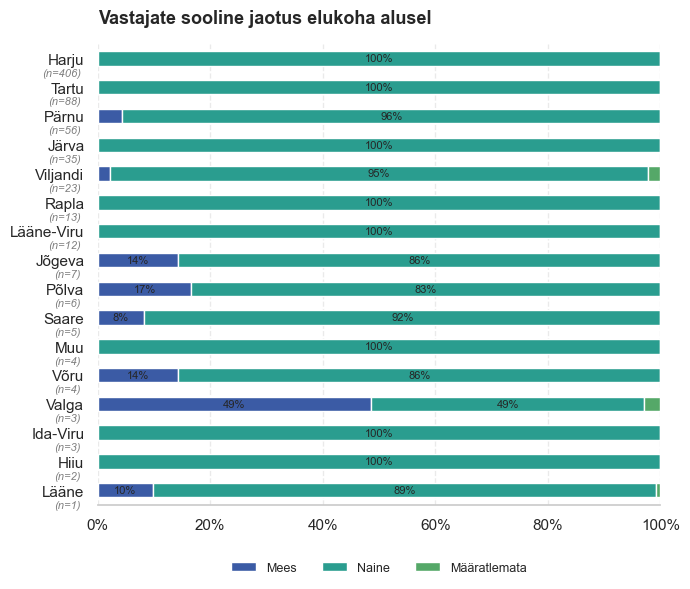

In [19]:
# Sooline jaotus elukoha alusel
loo_hor_stacked_tulpdiagramm(
    sugu_elukoht,
    'Vastajate sooline jaotus elukoha alusel',
    style
)

plt.show()

In [20]:
# Peamise koduse keele jaotus elukoha alusel
keel_elukoht = loo_risttabel(data, koodid, 'K5_elukoht', 'K6_keel')

keel_elukoht

K6_keel,Eesti,Inglise,Vene,Muu
K5_elukoht,,,,
Harju,383,6,13,4
Hiiu,2,0,0,0
Ida-Viru,3,0,0,0
Järva,34,0,0,1
Jõgeva,7,0,0,0
Lääne,1,0,0,0
Lääne-Viru,12,0,0,0
Põlva,6,0,0,0
Pärnu,56,0,0,0


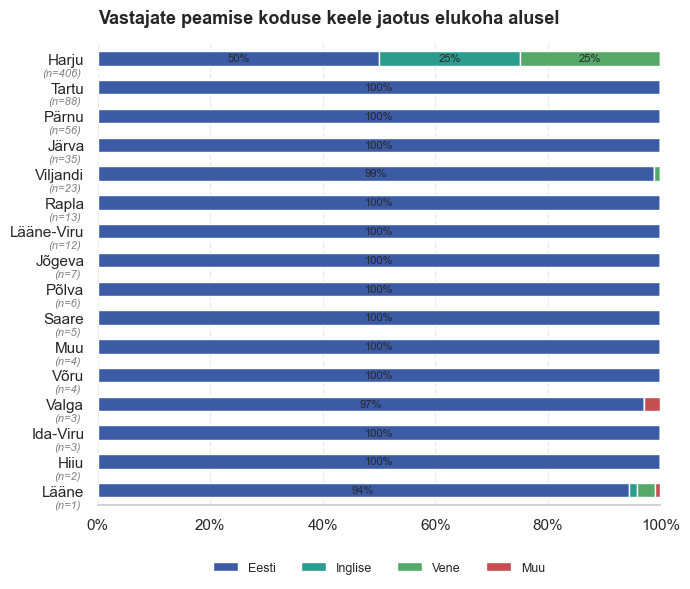

In [21]:
# Peamise koduse keele jaotus elukoha alusel
loo_hor_stacked_tulpdiagramm(
    keel_elukoht,
    'Vastajate peamise koduse keele jaotus elukoha alusel',
    style
)

plt.show()

In [22]:
# Vastajate sooline jaotus vanuse alusel risttabel
vanus_sugu = loo_risttabel(data, koodid, 'K3_vanus', 'K4_sugu')

vanus_sugu

K4_sugu,Mees,Naine,Määratlemata
K3_vanus,,,
<17,23,32,2
18-29,18,103,3
30-49,27,342,1
50-64,3,101,0
65>,0,13,0


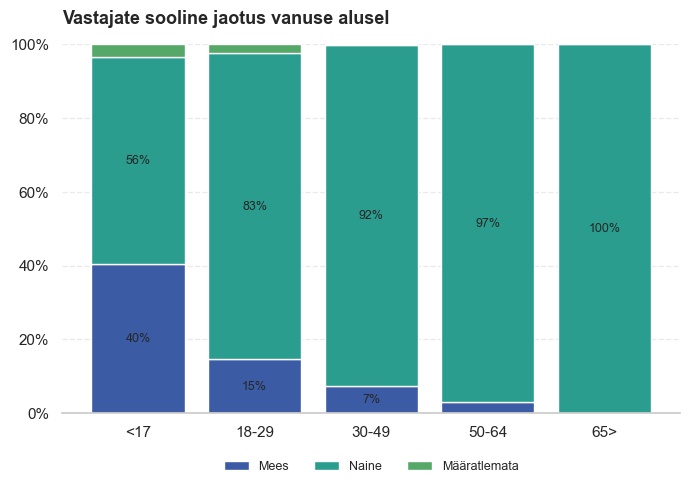

In [23]:
# Vastajate sooline jaotus vanuse alusel risttabel
loo_stacked_tulpdiagramm(
    vanus_sugu,
    'Vastajate sooline jaotus vanuse alusel',
    style
)

plt.show()

In [24]:
# Vastajate peamine kodune keel vanuse alusel risttabel
vanus_keel = loo_risttabel(data, koodid, 'K3_vanus', 'K6_keel')

vanus_keel

K6_keel,Eesti,Inglise,Vene,Muu
K3_vanus,,,,
<17,51,0,3,3
18-29,116,2,5,1
30-49,359,4,6,1
50-64,103,1,0,0
65>,12,0,1,0


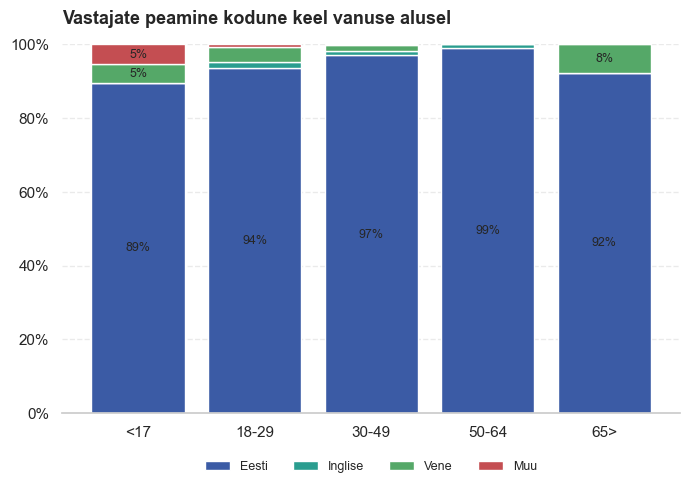

In [25]:
loo_stacked_tulpdiagramm(
    vanus_keel,
    'Vastajate peamine kodune keel vanuse alusel',
    style
)

plt.show()

In [26]:
# Peamine kodune keel soo alusel risttabel
sugu_keel = loo_risttabel(data, koodid, 'K4_sugu', 'K6_keel')

sugu_keel

K6_keel,Eesti,Inglise,Vene,Muu
K4_sugu,,,,
Mees,67,1,1,2
Naine,568,6,14,3
Määratlemata,6,0,0,0


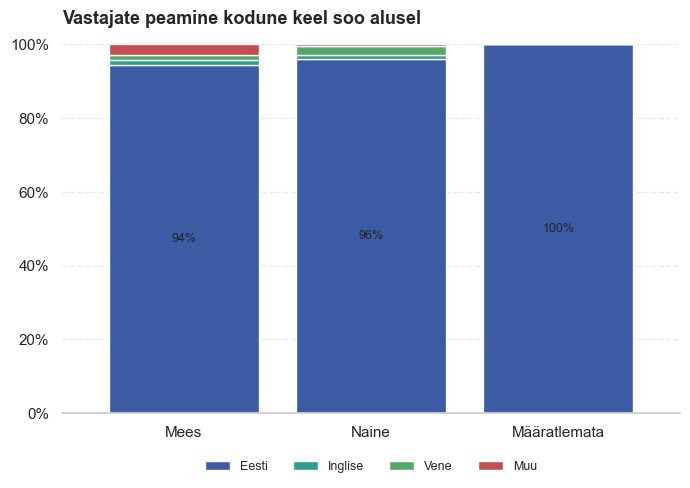

In [27]:
loo_stacked_tulpdiagramm(
    sugu_keel,
    'Vastajate peamine kodune keel soo alusel',
    style
)

plt.show()

## Tarbijate teadmised ja teadlikkus

K8_teadmiste_hinnang Kuidas hindad enda teadmisi jätkusuutlike valikute tegemisel rõivaste ja tekstiilide valdkonnas üleüldiselt (rõivaste ja kodutekstiilide ostmine, hooldamine parandamine jne)?

In [28]:
# Leia vastajate arv teadmiste hinnangu alusel
teadmiste_hinnang = sagedustabel(data_puhastatud, koodid, 'K8_teadmiste_hinnang')
teadmiste_hinnang

,kood,vastus_lyhike,vastuste_arv,protsent,protsent_str
36,1,Väga madal,19,3,3%
37,2,Pigem madal,58,9,9%
38,3,Keskmine,243,36,36%
39,4,Pigem hea,279,42,42%
40,5,Väga hea,69,10,10%


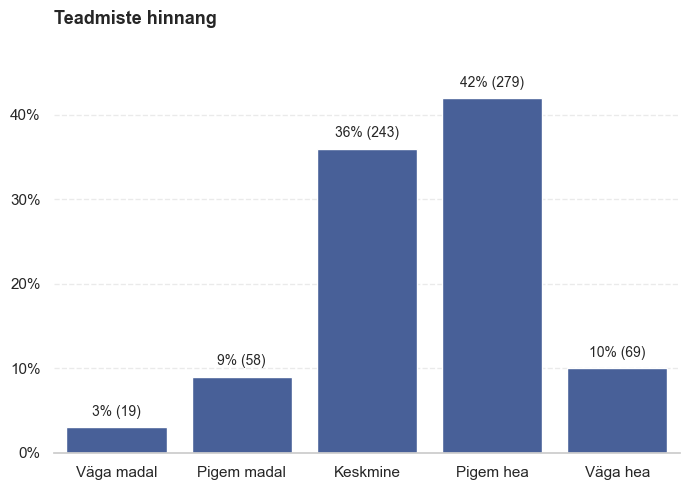

In [29]:
# Teadmiste hinnangu jaotuse tulpdiagramm
loo_tulpdiagramm(
    teadmiste_hinnang,
    'Teadmiste hinnang',
    style
)

plt.show()

In [30]:
# Noored peavad ennast teadlikumaks
# Teadmiste hinnang vanuse alusel
teadmised_vanus = loo_risttabel(data_puhastatud, koodid, 'K3_vanus', 'K8_teadmiste_hinnang')

teadmised_vanus

K8_teadmiste_hinnang,Väga madal,Pigem madal,Keskmine,Pigem hea,Väga hea
K3_vanus,,,,,
<17,3,10,25,15,4
18-29,4,13,51,49,7
30-49,8,30,132,164,36
50-64,2,5,32,44,21
65>,2,0,3,7,1


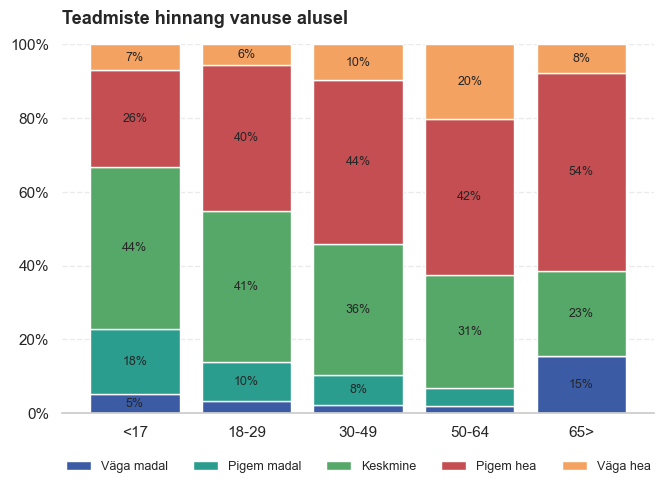

In [31]:
loo_stacked_tulpdiagramm(
    teadmised_vanus,
    'Teadmiste hinnang vanuse alusel',
    style
)

plt.show()

K9_probleemi_tosidus Kuidas hindad tekstiilijäätmete probleemi tõsidust Eestis ja globaalses mastaabis?

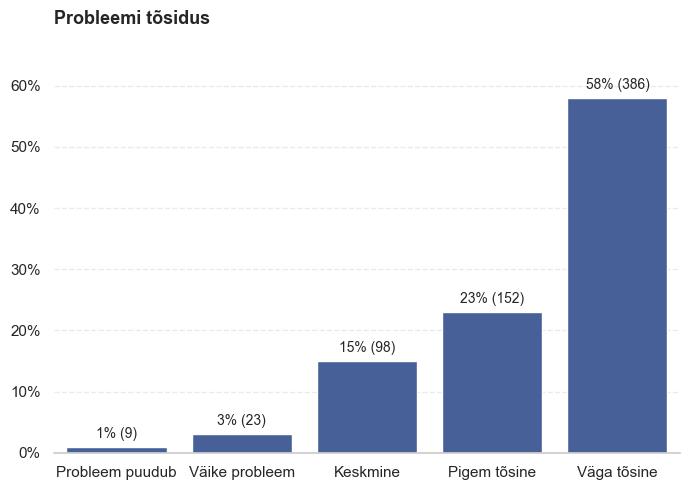

In [32]:
# Leia vastajate arv probleemi tõsiduse hinnangu alusel
probleemi_tosidus = sagedustabel(data, koodid, 'K9_probleemi_tosidus')

# Probleemi tõsiduse hinnangu jaotuse tulpdiagramm
loo_tulpdiagramm(
    probleemi_tosidus,
    'Probleemi tõsidus',
    style
)

plt.show()

In [33]:
# Noored hindavad probleemi vähemtõsisemaks
# Teadmiste hinnang vanuse alusel
tosidus_vanus = loo_risttabel(data_puhastatud, koodid, 'K3_vanus', 'K9_probleemi_tosidus')

tosidus_vanus

K9_probleemi_tosidus,Probleem puudub,Väike probleem,Keskmine,Pigem tõsine,Väga tõsine
K3_vanus,,,,,
<17,2,9,22,12,12
18-29,2,3,18,33,68
30-49,4,9,41,81,235
50-64,0,1,14,25,64
65>,1,1,3,1,7


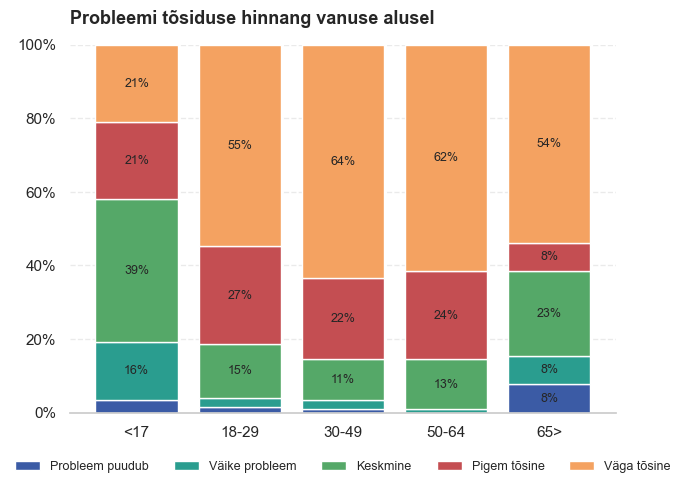

In [34]:
loo_stacked_tulpdiagramm(
    tosidus_vanus,
    'Probleemi tõsiduse hinnang vanuse alusel',
    style
)

plt.show()

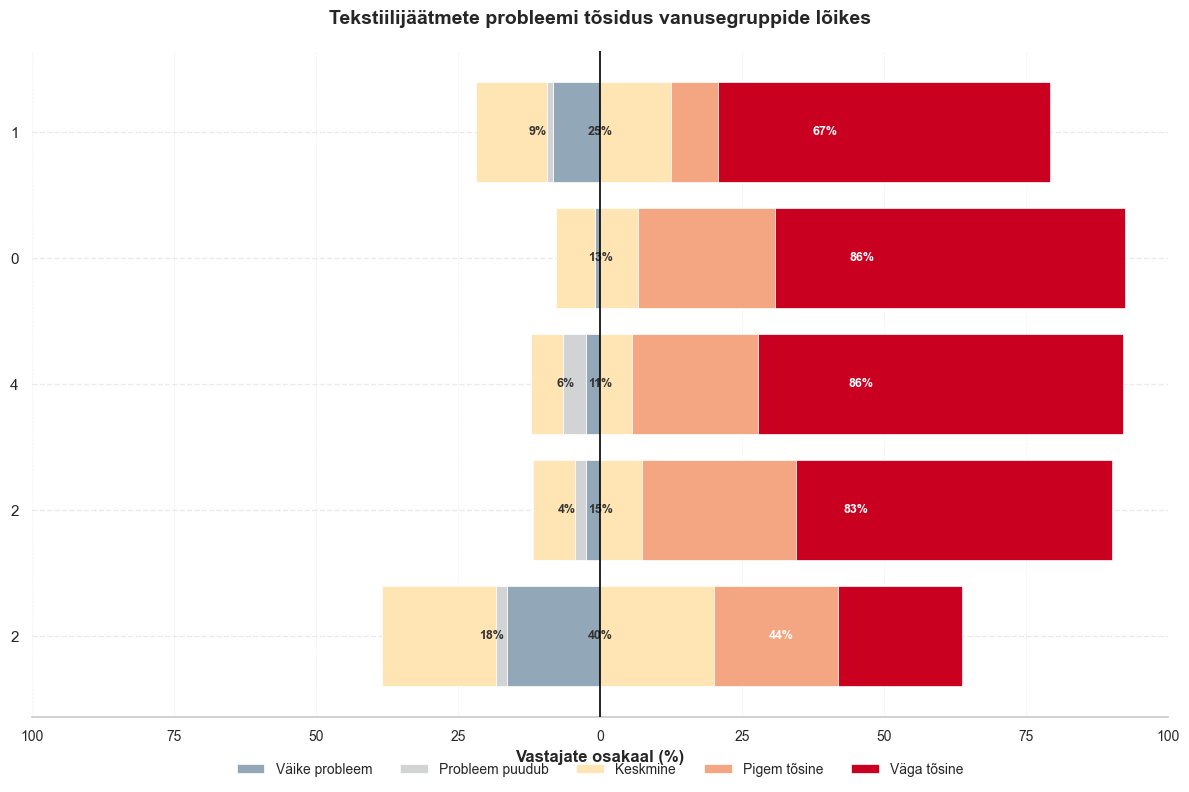

In [35]:
fig, ax = loo_diverging_stacked_tulpdiagramm(
    tosidus_vanus,
    'Tekstiilijäätmete probleemi tõsidus vanusegruppide lõikes',
    negatiivne_veerud=['Probleem puudub', 'Väike probleem'],
    neutraalne_veerg='Keskmine',
    positiivne_veerud=['Pigem tõsine', 'Väga tõsine'],
    naita_protsente=True
)

plt.show()

### Teadlikkus 2025. aastal Eestis kehtima hakanud seadusest

K11_teadlikkus Kas oled teadlik, et alates 2025. aastast hakkas Eestis kehtima seadus, mis nõuab tekstiilijäätmete liigiti kogumist?

In [36]:
# Leia vastajate arv teadlikkuse alusel
teadlikkus = sagedustabel(data_puhastatud, koodid, 'K11_teadlikkus')
teadlikkus

,kood,vastus_lyhike,vastuste_arv,protsent,protsent_str
46,1,"Jah, olen teadlik",252,38,38%
47,2,"Olen kuulnud, täpsemalt ei tea",222,33,33%
48,3,"Olen teadlik, ei pea tarbijate mureks",5,1,1%
49,4,Ei ole teadlik,189,28,28%


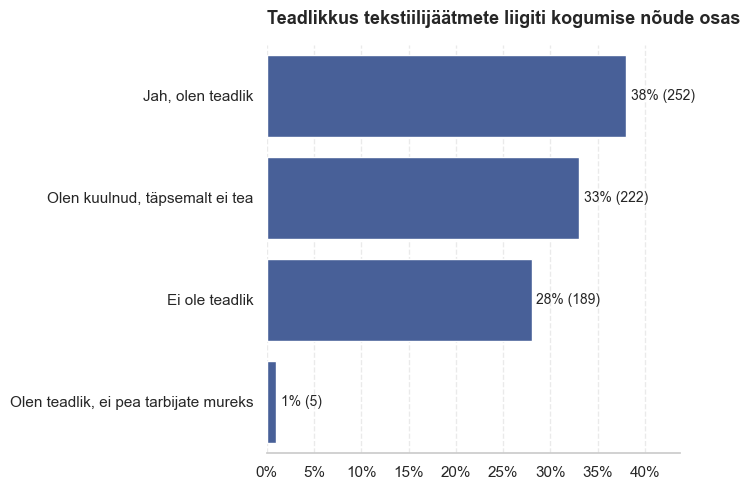

In [37]:
# Teadlikuse jaotuse tulpdiagramm
loo_hor_tulpdiagramm(
    teadlikkus,
    'Teadlikkus tekstiilijäätmete liigiti kogumise nõude osas',
    style,
    sort=True
)

plt.show()

In [38]:
# Teadlikkus vanuse alusel
teadlikkus_vanus = loo_risttabel(data_puhastatud, koodid, 'K3_vanus', 'K11_teadlikkus')
teadlikkus_vanus

K11_teadlikkus,"Jah, olen teadlik","Olen kuulnud, täpsemalt ei tea","Olen teadlik, ei pea tarbijate mureks",Ei ole teadlik
K3_vanus,,,,
<17,12,13,2,30
18-29,37,36,0,51
30-49,148,128,1,93
50-64,49,41,1,13
65>,6,4,1,2


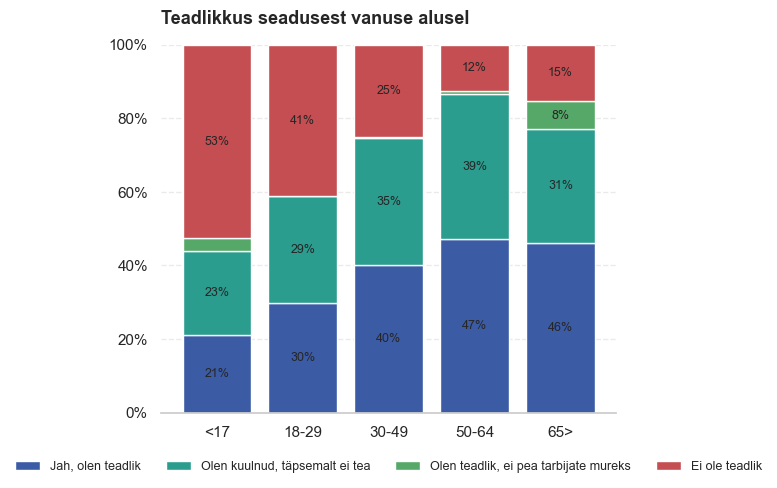

In [39]:
loo_stacked_tulpdiagramm(
    teadlikkus_vanus,
    'Teadlikkus seadusest vanuse alusel',
    style
)

plt.show()

In [40]:
# Teadlikkus elukoha alusel
teadlikkus_elukoht = loo_risttabel(data_puhastatud, koodid, 'K5_elukoht', 'K11_teadlikkus')
teadlikkus_elukoht 

K11_teadlikkus,"Jah, olen teadlik","Olen kuulnud, täpsemalt ei tea","Olen teadlik, ei pea tarbijate mureks",Ei ole teadlik
K5_elukoht,,,,
Harju,147,144,3,112
Järva,7,4,1,23
Pärnu,35,11,0,10
Tartu,31,29,1,27
Viljandi,4,13,0,6
Muu,28,21,0,11


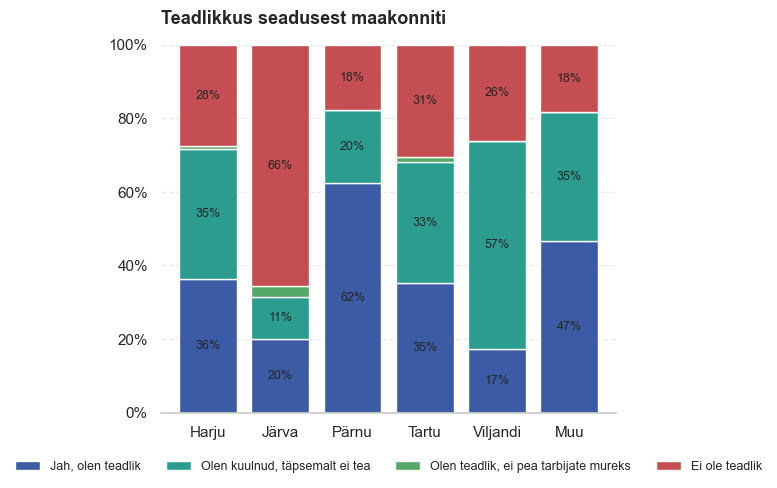

In [41]:
loo_stacked_tulpdiagramm(
    teadlikkus_elukoht,
    'Teadlikkus seadusest maakonniti',
    style
)

plt.show()

In [42]:
# Teadlikkus × hinnang enda teadmistele
teadlikkus_teadmised = loo_risttabel(data_puhastatud, koodid, 'K8_teadmiste_hinnang', 'K11_teadlikkus')
teadlikkus_teadmised

K11_teadlikkus,"Jah, olen teadlik","Olen kuulnud, täpsemalt ei tea","Olen teadlik, ei pea tarbijate mureks",Ei ole teadlik
K8_teadmiste_hinnang,,,,
Väga madal,0,7,0,12
Pigem madal,7,19,1,31
Keskmine,70,88,1,84
Pigem hea,131,91,3,54
Väga hea,44,17,0,8


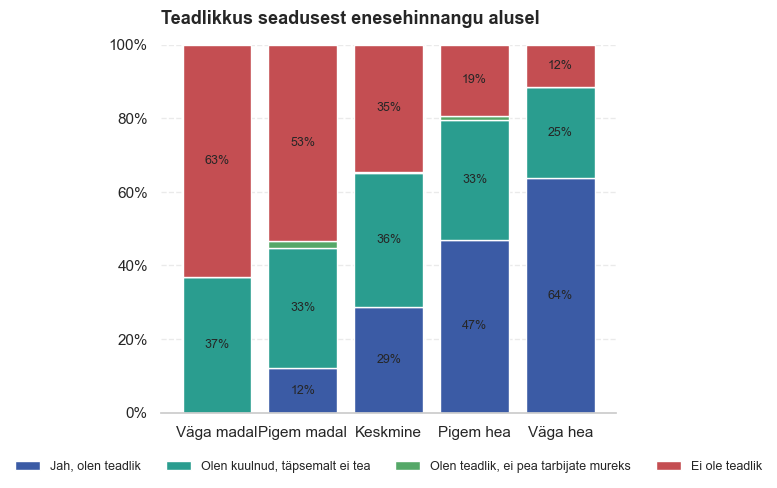

In [43]:
loo_stacked_tulpdiagramm(
    teadlikkus_teadmised, 
    'Teadlikkus seadusest enesehinnangu alusel',
    style
)

plt.show()


<Axes: xlabel='K11_teadlikkus', ylabel='K8_teadmiste_hinnang'>

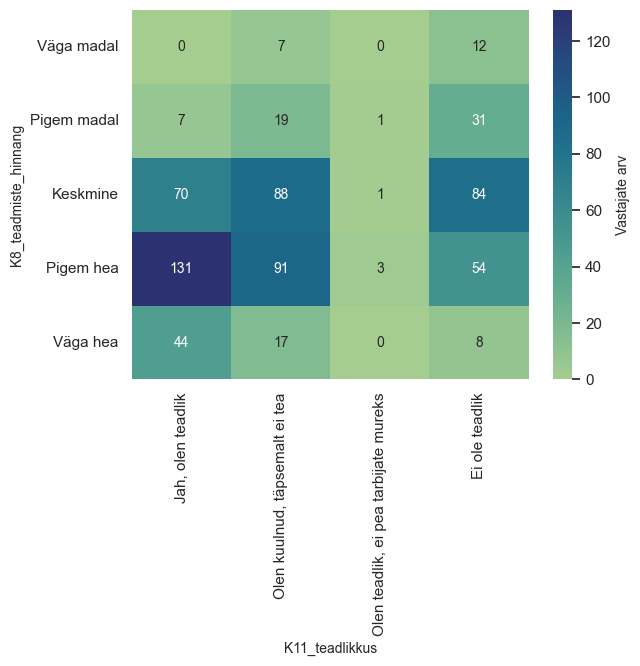

In [ ]:
sns.heatmap(teadlikkus_teadmised, annot=True, fmt='.1f', cmap='crest', 
            cbar_kws={'label': 'Vastajate arv'}) # protsendi kuvamiseks fmt='.1f'

In [45]:
# Teadlikkus × Probleemi tõsidus
teadlikkus_probleem = loo_risttabel(data_puhastatud, koodid, 'K9_probleemi_tosidus', 'K11_teadlikkus')
teadlikkus_probleem


K11_teadlikkus,"Jah, olen teadlik","Olen kuulnud, täpsemalt ei tea","Olen teadlik, ei pea tarbijate mureks",Ei ole teadlik
K9_probleemi_tosidus,,,,
Probleem puudub,1,2,0,6
Väike probleem,3,1,1,18
Keskmine,15,35,1,47
Pigem tõsine,54,50,1,47
Väga tõsine,179,134,2,71


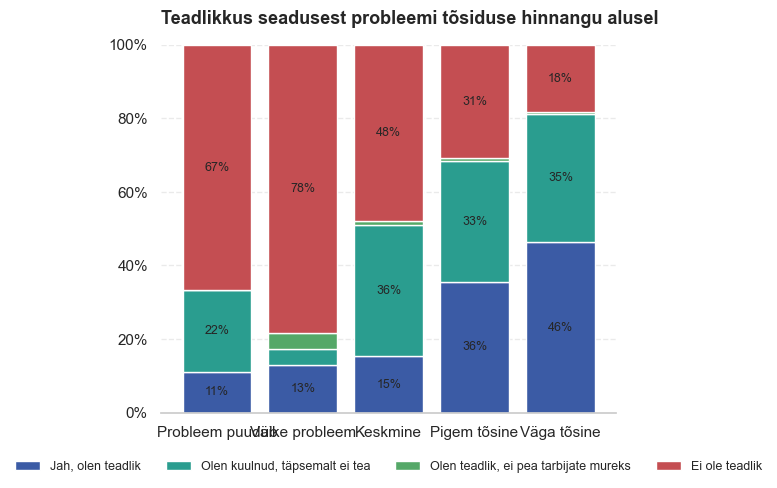

In [46]:
loo_stacked_tulpdiagramm(
    teadlikkus_probleem,
    'Teadlikkus seadusest probleemi tõsiduse hinnangu alusel',
    style
)

plt.show()

K13_kommunikatsiooni_selgus Kui selge on olnud KOV-ide kommunikatsioon seoses tekstiilide liigiti kogumise nõudega alates 2025. aasta algusest?

In [47]:
# Leia vastajate arv kommunikatsiooni selguse alusel
kommunikatsiooni_selgus = sagedustabel(data_puhastatud, koodid, 'K13_kommunikatsiooni_selgus')

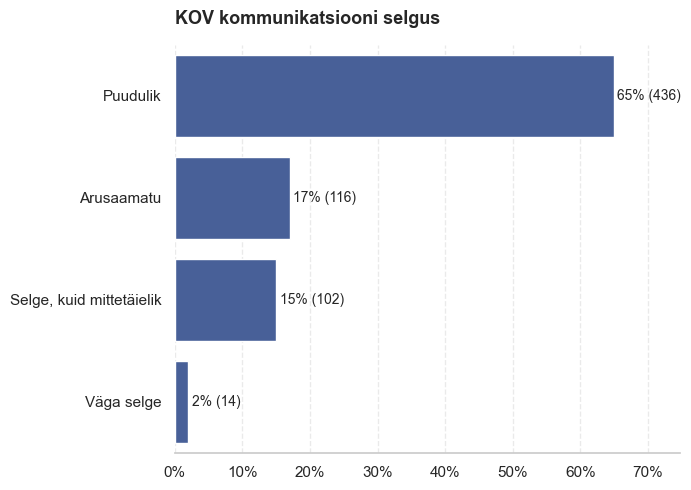

In [48]:
# Kommunikatsiooni selguse jaotuse tulpdiagramm
loo_hor_tulpdiagramm(
    kommunikatsiooni_selgus,
    'KOV kommunikatsiooni selgus',
    style,
    sort=True
)

plt.show()

In [49]:
# Kommunikatsiooni selgus elukoha alusel risttabel
kommunikatsioon_elukoht = loo_risttabel(data_puhastatud, koodid, 'K5_elukoht', 'K13_kommunikatsiooni_selgus')

kommunikatsioon_elukoht

K13_kommunikatsiooni_selgus,Väga selge,"Selge, kuid mittetäielik",Arusaamatu,Puudulik
K5_elukoht,,,,
Harju,7,57,66,276
Järva,0,7,9,19
Pärnu,2,16,12,26
Tartu,2,12,16,58
Viljandi,0,2,4,17
Muu,3,8,9,40


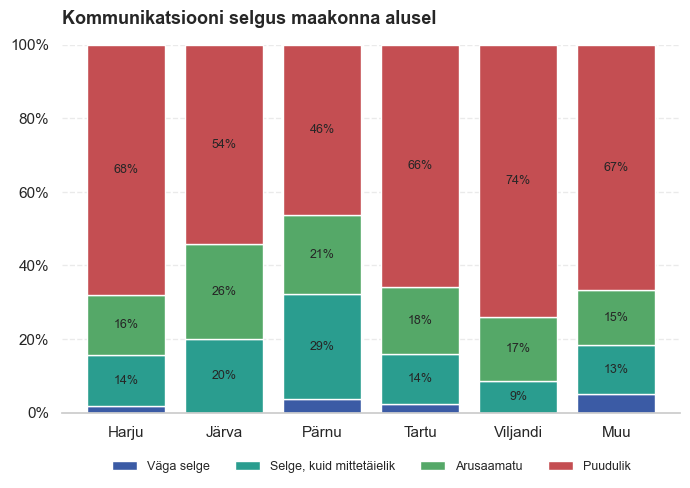

In [50]:
loo_stacked_tulpdiagramm(
    kommunikatsioon_elukoht,
    'Kommunikatsiooni selgus maakonna alusel',
    style
)

plt.show()

In [51]:
# Kas parem kommunikatsioon näitab kõrgemat teadlikkust seadusest?
selgus_teadlikkus = loo_risttabel(data_puhastatud, koodid, 'K13_kommunikatsiooni_selgus', 'K11_teadlikkus')

selgus_teadlikkus

K11_teadlikkus,"Jah, olen teadlik","Olen kuulnud, täpsemalt ei tea","Olen teadlik, ei pea tarbijate mureks",Ei ole teadlik
K13_kommunikatsiooni_selgus,,,,
Väga selge,10,1,0,3
"Selge, kuid mittetäielik",64,33,2,3
Arusaamatu,41,50,3,22
Puudulik,137,138,0,161


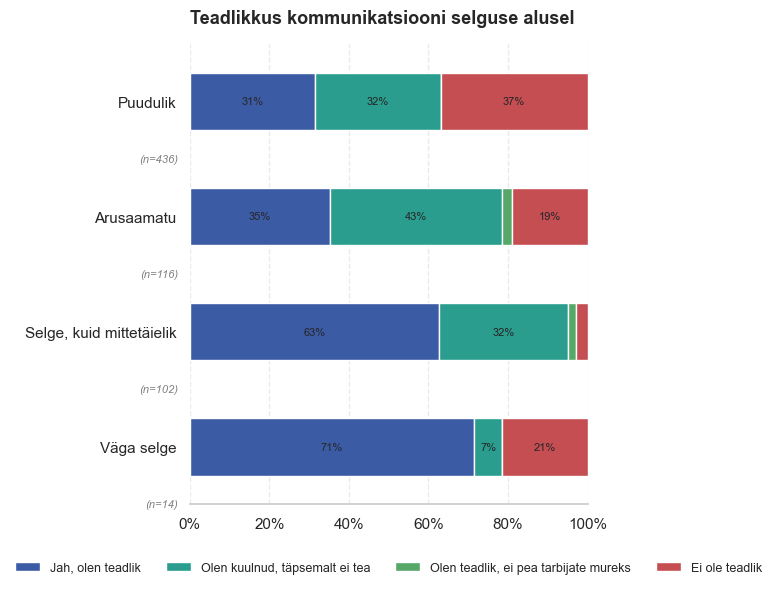

In [52]:
loo_hor_stacked_tulpdiagramm(
    selgus_teadlikkus,
    'Teadlikkus kommunikatsiooni selguse alusel',
    style
)

plt.show()

K28_riikliku_juhise_selgus Kas tänane riiklik tekstiilide kogumisjuhis on piisavalt selge ja arusaadav?

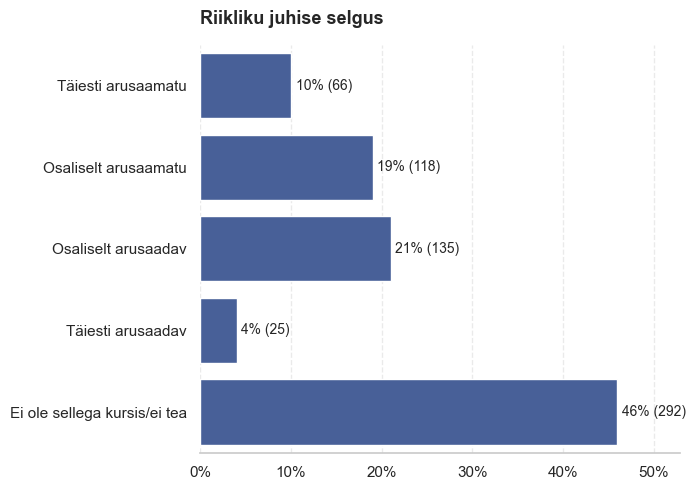

In [53]:
# Leia vastajate arv riikliku juhise selguse alusel
juhise_selgus = sagedustabel(data, koodid, 'K28_riikliku_juhise_selgus')

# Kommunikatsiooni selguse jaotuse tulpdiagramm
loo_hor_tulpdiagramm(
    juhise_selgus,
    'Riikliku juhise selgus',
    style
    #,sort=True
)

plt.show()

In [54]:
# Riikliku juhise selgus kommunikatsiooni selguse alusel
selgus_juhis = loo_risttabel(data_puhastatud, koodid, 'K13_kommunikatsiooni_selgus', 'K28_riikliku_juhise_selgus')
selgus_juhis

K28_riikliku_juhise_selgus,Täiesti arusaamatu,Osaliselt arusaamatu,Osaliselt arusaadav,Täiesti arusaadav,Ei ole sellega kursis/ei tea
K13_kommunikatsiooni_selgus,,,,,
Väga selge,1,5,3,2,2
"Selge, kuid mittetäielik",3,26,31,14,20
Arusaamatu,11,25,37,5,32
Puudulik,51,62,64,4,238


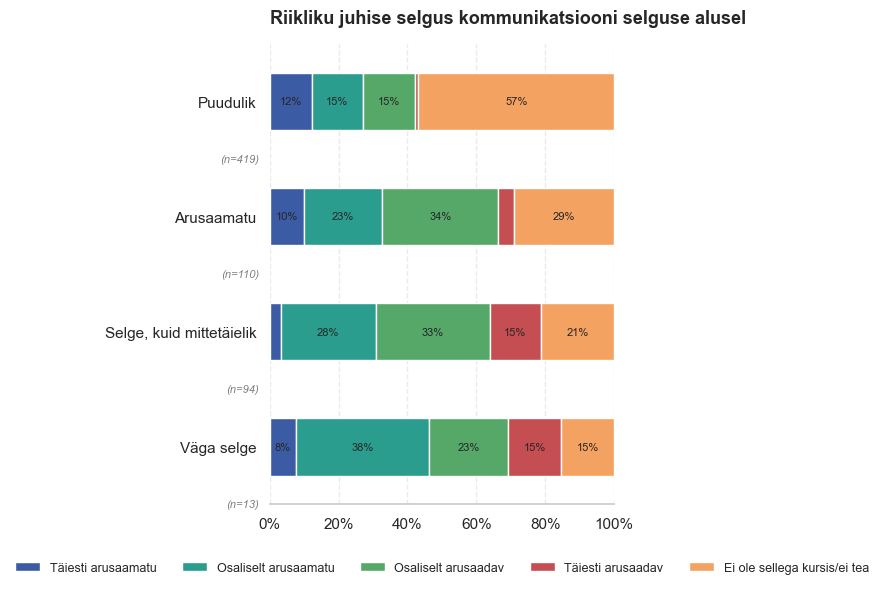

In [55]:
loo_hor_stacked_tulpdiagramm(
    selgus_juhis,
    'Riikliku juhise selgus kommunikatsiooni selguse alusel',
    style
)

plt.show()

## Tarbijakäitumine

### Sorteerimiskäitumine

Kui palju sorteeritakse?

mitte-sorteerijaid 4,5%

3+ kategoorias sorteerib 83,6%

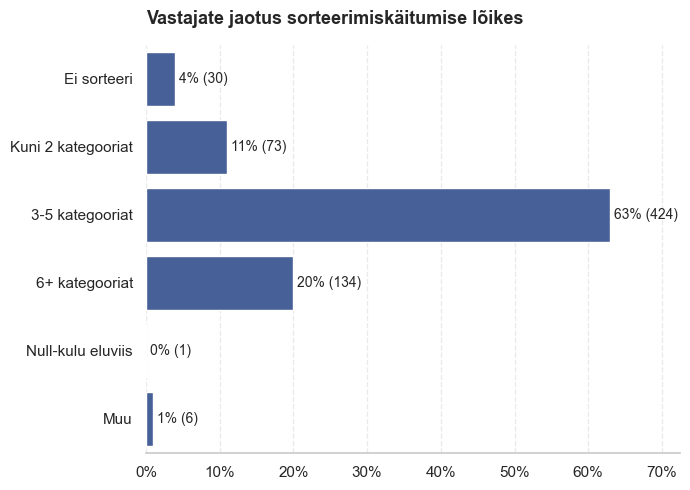

In [56]:
# Leia vastajate arv sorteerimiskäitumise alusel
sorteerimiskaitumine = sagedustabel(data, koodid, 'K7_sorteerimiskaitumine')

# Sorteerimiskäitumise jaotuse tulpdiagramm
loo_hor_tulpdiagramm(
    sorteerimiskaitumine,
    'Vastajate jaotus sorteerimiskäitumise lõikes',
    style
)

plt.show()

In [57]:
# Vastajate sorteerimiskäitumine vanuse alusel risttabel
vanus_sorteerimiskaitumine = loo_risttabel(data, koodid, 'K3_vanus', 'K7_sorteerimiskaitumine')
vanus_sorteerimiskaitumine

K7_sorteerimiskaitumine,Ei sorteeri,Kuni 2 kategooriat,3-5 kategooriat,6+ kategooriat,Null-kulu eluviis,Muu
K3_vanus,,,,,,
<17,7,15,30,3,0,2
18-29,12,22,76,14,0,0
30-49,9,29,235,94,0,3
50-64,2,5,73,22,1,1
65>,0,2,10,1,0,0


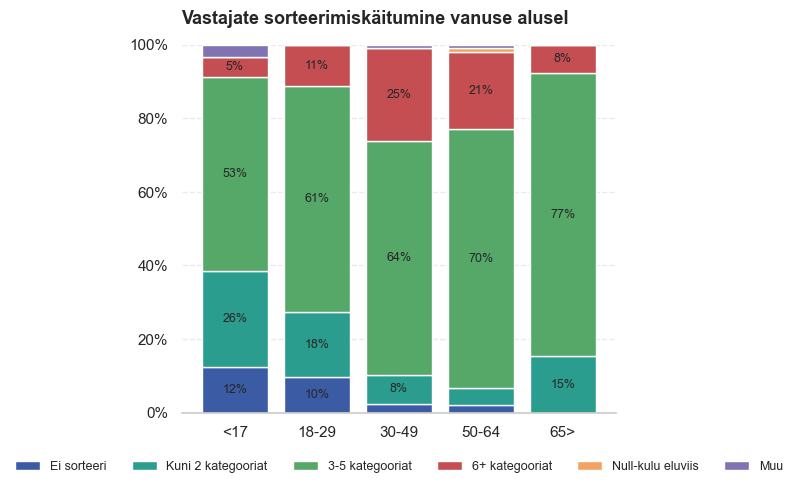

In [58]:
# Sorteerimiskäitumine vanuse alusel
loo_stacked_tulpdiagramm(
    vanus_sorteerimiskaitumine,
    'Vastajate sorteerimiskäitumine vanuse alusel',
    style
)

plt.show()

In [59]:
# Sorteerimiskäitumine elukoha alusel
elukoht_sorteerimiskaitumine = loo_risttabel(data, koodid, 'K5_elukoht', 'K7_sorteerimiskaitumine')

elukoht_sorteerimiskaitumine

K7_sorteerimiskaitumine,Ei sorteeri,Kuni 2 kategooriat,3-5 kategooriat,6+ kategooriat,Null-kulu eluviis,Muu
K5_elukoht,,,,,,
Harju,16,50,258,80,0,2
Hiiu,0,0,2,0,0,0
Ida-Viru,0,0,3,0,0,0
Järva,2,7,22,2,0,2
Jõgeva,2,0,3,2,0,0
Lääne,0,0,0,1,0,0
Lääne-Viru,2,0,9,1,0,0
Põlva,0,0,4,2,0,0
Pärnu,1,5,36,14,0,0


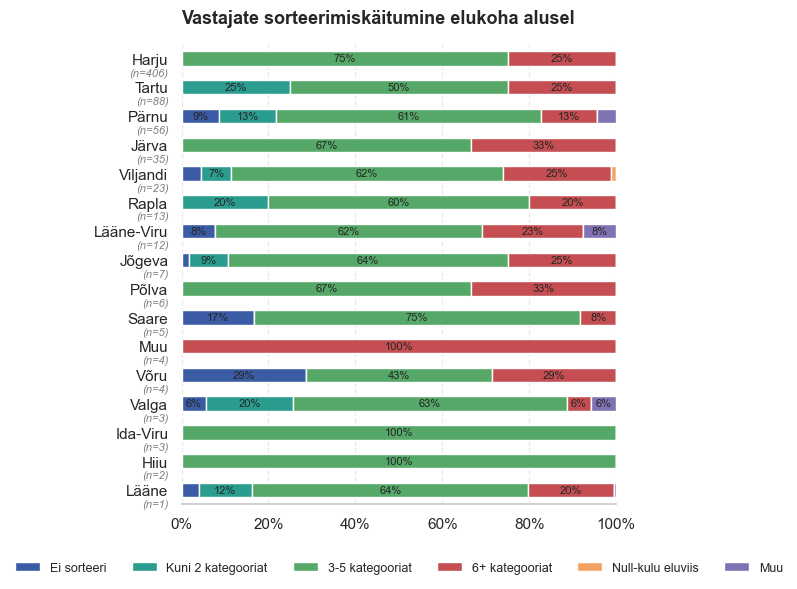

In [60]:
loo_hor_stacked_tulpdiagramm(
    elukoht_sorteerimiskaitumine,
    'Vastajate sorteerimiskäitumine elukoha alusel',
    style
)

plt.show()

Kes on mitte-sorteerijad?

In [61]:
# mitte_sorteerijad = data[data['K7_sorteerimiskaitumine'] == 1]
print(f'Vastanutest ei sorteeri üheski kategoorias: {sorteerimiskaitumine.loc[sorteerimiskaitumine['kood']==1, 'protsent_str'].to_string(index=False)}')

# Leia vastajad, kes ei sorteeri
df_alam = data[data['K7_sorteerimiskaitumine'] == 1]

mitte_sorteerijad = loo_risttabel(df_alam, koodid, 'K5_elukoht', 'K3_vanus')

mitte_sorteerijad

# KUNA MITTE-SORTEERIJAID VASTANUTE HULGAS NII VÄHE, SIIS EI SAA MINGEID JÄRELDUSI TEHA

Vastanutest ei sorteeri üheski kategoorias: 4%


K3_vanus,<17,18-29,30-49,50-64
K5_elukoht,,,,
Harju,3,9,4,0
Järva,2,0,0,0
Jõgeva,0,0,0,2
Lääne-Viru,1,0,1,0
Pärnu,0,0,1,0
Rapla,0,0,1,0
Tartu,1,2,1,0
Viljandi,0,1,1,0


In [62]:
# Grupeeri sorteerimiskäitumine, kus 3, 4 ja 5 on kokku võetud kategooriasse 3 (sordi rohkem kui 2 kategooriasse) ning loo koodid ja vastused selle põhjal
sorteerimine = data[['K7_sorteerimiskaitumine']].replace([3, 4, 5], 3)
sort_koodid = {
  'kysimus': ['K7_sorteerimiskaitumine', 'K7_sorteerimiskaitumine', 'K7_sorteerimiskaitumine'],
  'kood': [1, 3, 6],
  'vastus': ['Ei sorteeri', '>2 kategoorias', 'Muu'],
  'vastus_lyhike': ['Ei sorteeri','>2 kategoorias', 'Muu']
}
sort_koodid = pd.DataFrame(sort_koodid)

sorteerimiskaitumine_grupeeritud = sagedustabel(sorteerimine, sort_koodid, 'K7_sorteerimiskaitumine', use_full_codebook=False)
print(f'Vastanutest {sorteerimiskaitumine_grupeeritud.loc[sorteerimiskaitumine_grupeeritud['kood']==3, 'protsent_str'].to_string(index=False)} sorteerib 3-s või enamas kategoorias')

Vastanutest 84% sorteerib 3-s või enamas kategoorias


In [63]:
sorteerimiskaitumine_grupeeritud

,kood,vastus_lyhike,vastuste_arv,protsent,protsent_str
0,3,>2 kategoorias,559,84,84%
1,2,NaN,73,11,11%
2,1,Ei sorteeri,30,4,4%
3,6,Muu,6,1,1%


In [64]:
print(f'Vastanutest sorteerib 3-s ja enamas kategoorias {sorteerimiskaitumine.loc[sorteerimiskaitumine['kood'].isin([3,4,5]), 'protsent'].sum():.1f}% vastanutest')

# Leia vastajad, kes sorteerivad 3 ja enamas kategoorias
df_alam = data[data['K7_sorteerimiskaitumine'].isin([3,4,5])]

#df_alam['K5_elukoht'] = df_alam['K5_elukoht'].map(elukoht_sildid)
#df_alam['K3_vanus'] = df_alam['K3_vanus'].map(vanus_sildid)

#sorteerijad = pd.crosstab(index=df_alam['K5_elukoht'], columns=df_alam['K3_vanus'])
sorteerijad = loo_risttabel(df_alam, koodid, 'K5_elukoht', 'K3_vanus')

# vanus_sorteerimiskaitumine.columns = elukoht_sildid.values()
#vanus_sorteerimiskaitumine.index = vanus_sildid.values()

sorteerijad


Vastanutest sorteerib 3-s ja enamas kategoorias 83.0% vastanutest


K3_vanus,<17,18-29,30-49,50-64,65>
K5_elukoht,,,,,
Harju,12,54,210,53,9
Hiiu,0,0,2,0,0
Ida-Viru,0,1,1,1,0
Järva,16,4,2,2,0
Jõgeva,1,1,2,1,0
Lääne,0,0,0,1,0
Lääne-Viru,1,5,4,0,0
Põlva,0,0,4,1,1
Pärnu,0,7,32,11,0


<Axes: xlabel='K3_vanus', ylabel='K5_elukoht'>

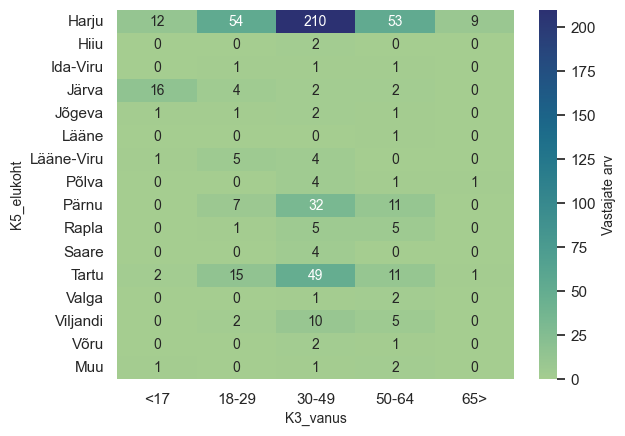

In [65]:
sns.heatmap(sorteerijad, annot=True, fmt='.0f', cmap='crest', 
            cbar_kws={'label': 'Vastajate arv'}) # protsendi kuvamiseks fmt='.1f'

In [66]:
# grouped_data = data.groupby(['K3_vanus', 'K7_sorteerimiskaitumine']).size().reset_index(name='count')
# ax = sns.barplot(data=grouped_data, x='K3_vanus', y='count', hue='K7_sorteerimiskaitumine')

Kui suur on sinu leibkonnas ühe indiviidi kohta loobutud tekstiilide kogus ühes kalendriaastas?

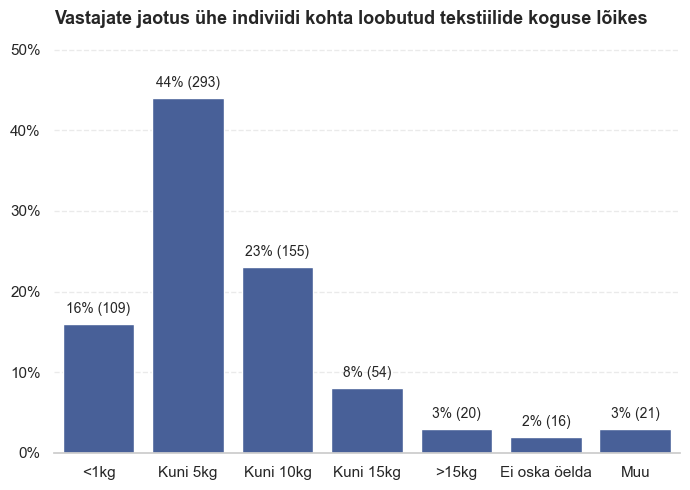

In [67]:
# Leia vastajate arv sorteerimiskäitumise alusel
tekstiilide_kogus = sagedustabel(data, koodid, 'K14_tekstiilide_kogus')

# Sorteerimiskäitumise jaotuse tulpdiagramm
loo_tulpdiagramm(
    tekstiilide_kogus,
    'Vastajate jaotus ühe indiviidi kohta loobutud tekstiilide koguse lõikes',
    style
)

plt.show()

Mida võtad peamiselt ette rõivaste või kodutekstiilidega, mida enam ei vaja?

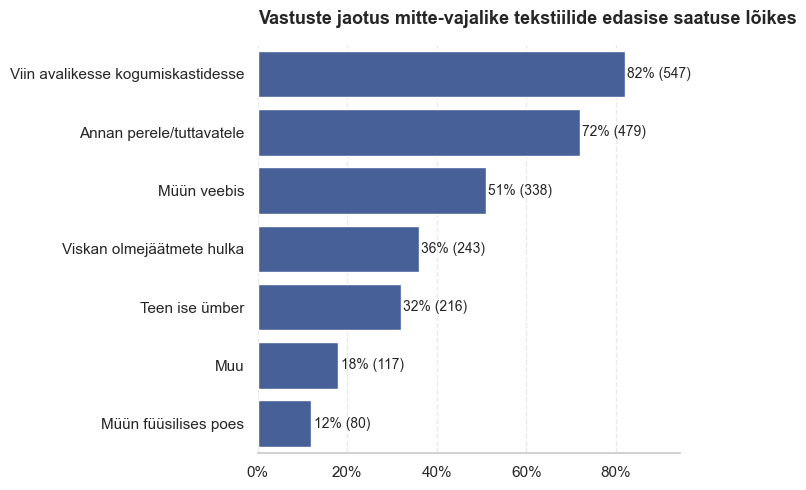

In [68]:
# Leia vastuste jaotus - mida võtavad vastajad ette mitte-vajalike tekstiilidega
mittevajalikud_tekstiilid = mitmikvastuse_sagedustabel(data, koodid, 'K15_mittevajalikud_tekstiilid')

loo_hor_tulpdiagramm(
    mittevajalikud_tekstiilid,
    'Vastuste jaotus mitte-vajalike tekstiilide edasise saatuse lõikes',
    style,
    sort=True   
)

plt.show()

In [69]:
vanus_mittevajalik = duckdb.sql('''
    select
        K3_vanus,
        sum(K15_mittevajalikud_tekstiilid_1)
        ,sum(K15_mittevajalikud_tekstiilid_2)
        ,sum(K15_mittevajalikud_tekstiilid_3)
    from data
    group by K3_vanus
    order by K3_vanus
''').df()

In [70]:
vanus_mittevajalik2 = data[[
    'K3_vanus',
    'K15_mittevajalikud_tekstiilid_1',
    'K15_mittevajalikud_tekstiilid_2']].groupby('K3_vanus').agg('sum')
vanus_mittevajalik2

,K15_mittevajalikud_tekstiilid_1,K15_mittevajalikud_tekstiilid_2
K3_vanus,,
1,14,9
2,81,12
3,215,46
4,28,13
5,0,0


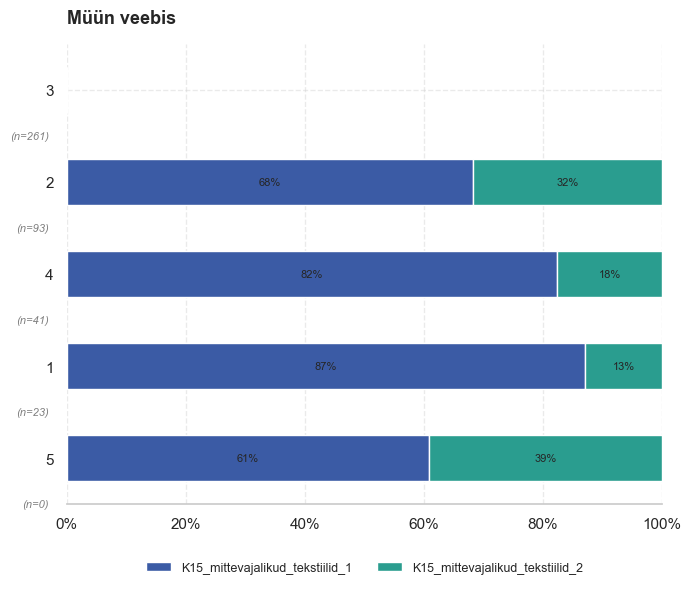

In [71]:
loo_hor_stacked_tulpdiagramm(
    vanus_mittevajalik2,
    'Müün veebis',
    style
)

plt.show()

In [72]:
# Vastajate mitte-vajalikest tekstiilidest loobumise jaotus vanuse alusel risttabel
vanus_sorteerimiskaitumine = loo_risttabel(data, koodid, 'K15_mittevajalikud_tekstiilid_1', 'K3_vanus')
vanus_sorteerimiskaitumine

K3_vanus,<17,18-29,30-49,50-64,65>
K15_mittevajalikud_tekstiilid_1,,,,,
0,43,43,155,76,13
1,14,81,215,28,0


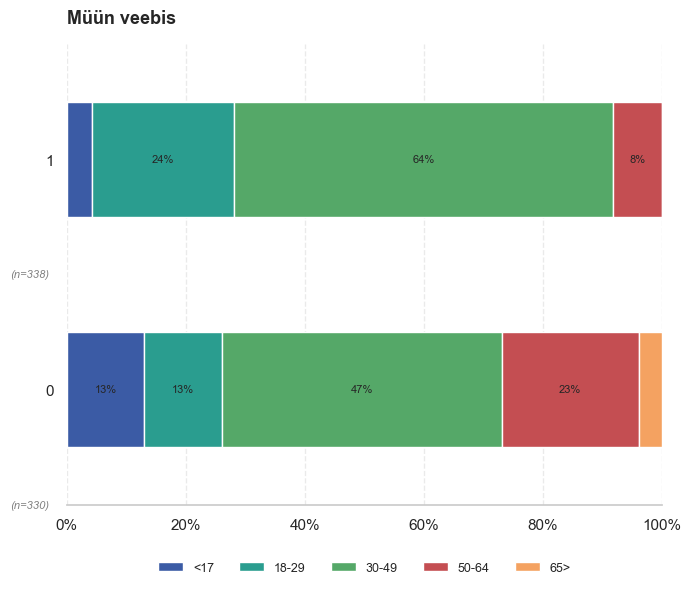

In [73]:
loo_hor_stacked_tulpdiagramm(
    vanus_sorteerimiskaitumine,
    'Müün veebis',
    style
)

plt.show()

Mis on peamised põhjused, miks enda rõivastest ja kodutekstiilidest oled viimase aasta jooksul loobunud?

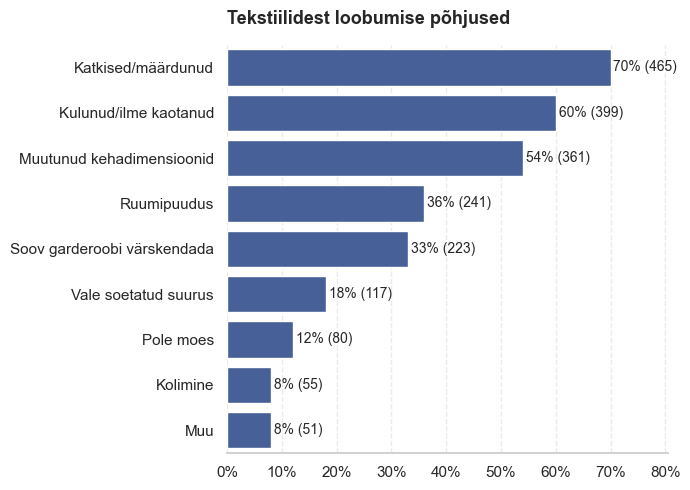

In [74]:
# Leia vastuste jaotus - mida võtavad vastajad ette mitte-vajalike tekstiilidega
loobumise_pohjused = mitmikvastuse_sagedustabel(data, koodid, 'K19_loobumise_pohjused')

loo_hor_tulpdiagramm(
    loobumise_pohjused,
    'Tekstiilidest loobumise põhjused',
    style,
    sort=True   
)

plt.show()

Kuhu viid peamiselt kasutuskõlbmatud rõivad ja tekstiilid?

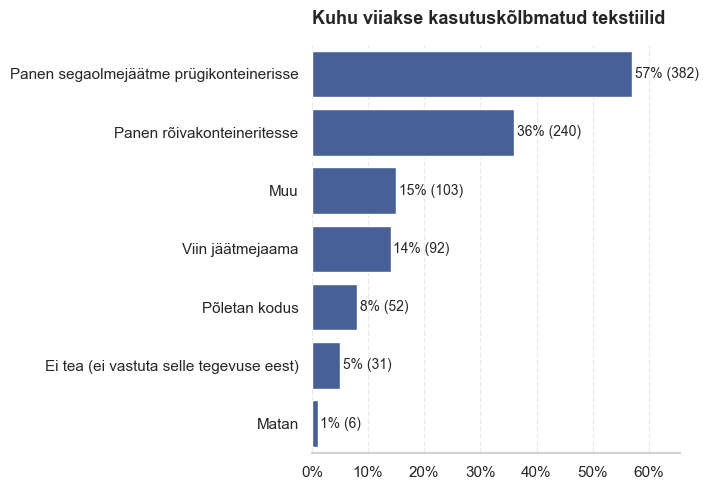

In [75]:
# Leia vastuste jaotus - mida võtavad vastajad ette mitte-vajalike tekstiilidega
kasutuskolbmatud_tekstiilid = mitmikvastuse_sagedustabel(data, koodid, 'K23_kasutuskolbmatud_tekstiilid')

loo_hor_tulpdiagramm(
    kasutuskolbmatud_tekstiilid,
    'Kuhu viiakse kasutuskõlbmatud tekstiilid',
    style,
    sort=True   
)

plt.show()

Kas oled teadlikult viinud tekstiilikonteineritesse rõivaid, mis korduskasutuseks ei sobi?

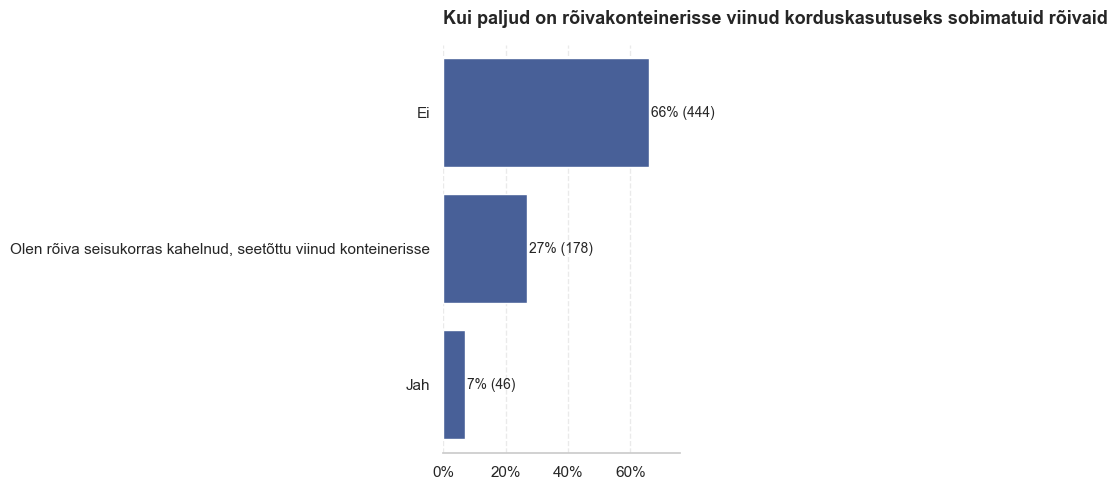

In [76]:
# Leia vastajate arv sorteerimiskäitumise alusel
korduskasutuseks_mittesobilik = sagedustabel(data, koodid, 'K26_korduskasutuseks_sobimatud_tekstiilid')

# Sorteerimiskäitumise jaotuse tulpdiagramm
loo_hor_tulpdiagramm(
    korduskasutuseks_mittesobilik,
    'Kui paljud on rõivakonteinerisse viinud korduskasutuseks sobimatuid rõivaid',
    style,
    sort=True 
)

plt.show()

## Tarbijate teadmised ja teadlikkus

## Descriptive Statistics for This Survey Dataset

Based on the data dictionary analysis, this is a **textile waste and consumer behavior survey** with 105 variables. Here are the appropriate descriptive statistics by variable type:

### **1. Demographic Variables (Categorical - Nominal/Ordinal)**

**Variables:** K3_vanus (age), K4_sugu (gender), K5_elukoht (location), K6_keel (language)

**Recommended statistics:**
- **Frequency distributions** - count and percentage for each category
- **Mode** - most common category
- **Cross-tabulations** - relationships between demographics
- **Bar charts/pie charts** for visualization

**Reasoning:** Nominal variables lack numerical meaning, so only frequency-based measures apply.

---

### **2. Likert Scale Variables (Ordinal - 1-5 scales)**

**Variables:** K8_teadmiste_hinnang, K9_probleemi_tosidus, K17_valmisolek_parandamiseks, K21_loobumise_lihtsus, K37_rahulolu_garderoobiga, K41_ultrakiirmoe_ostmine, K43_roivaste_tellimine_proovimiseks (7 total)

**Recommended statistics:**
- **Median** - central tendency (more appropriate than mean for ordinal data)
- **Mode** - most frequent response
- **Interquartile range (IQR)** - spread of middle 50%
- **Frequency distribution** - % at each scale point
- **Mean** (with caveat) - acceptable if treating as interval data
- **Standard deviation** (with caveat) - if treating as interval
- **Stacked bar charts** or **diverging stacked bar charts** for visualization

**Reasoning:** Likert scales are technically ordinal, but often analyzed as interval data. Median is statistically safer, but mean is commonly used for practical interpretation.

---

### **3. Multiple Choice Questions (Binary/Boolean)**

**Variable groups:** 
- K15_mittevajalikud_tekstiilid (7 options)
- K19_loobumise_pohjused (9 options) 
- K22_peamised_valjakutsed (7 options)
- K23_kasutuskolbmatud_tekstiilid (7 options)
- K25_loobumisel_oluline (7 options)
- K32_teabe_allikad (10 options)
- K33_julgustavad_tegurid (7 options)

**Recommended statistics:**
- **Selection frequency** - % who selected each option
- **Response rate** - % who answered the question
- **Total selections per respondent** (mean, median) - shows if people select 1 vs many
- **Co-occurrence matrix** - which options are selected together
- **Ranked order** by frequency

**Reasoning:** Each option is independent; statistics should show popularity and patterns of selection.

---

### **4. Single-Choice Categorical Variables (Nominal)**

**Variables:** K7_sorteerimiskaitumine, K26_korduskasutuseks_sobimatud_tekstiilid, K28_riikliku_juhise_selgus, K29_sobiv_kogumisviis, K30_valmisolek_kategoriseerimiseks, K38_kandmise_kestus, K40_ostmissagedus

**Recommended statistics:**
- **Frequency table** - count and percentage
- **Mode** - most common choice
- **Diversity index** (optional) - how evenly distributed responses are
- **Chi-square tests** for associations with demographics

**Reasoning:** These are mutually exclusive categories without inherent order.

---

### **Summary Statistics Report Structure**

A complete analysis should include:

1. **Sample characteristics** (n, completion rate, demographics)
2. **Central tendency measures** (mean/median by variable type)
3. **Dispersion measures** (SD, IQR, range)
4. **Distribution analysis** (frequency tables, histograms)
5. **Bivariate analysis** (correlations, cross-tabs by demographics)
6. **Missing data analysis** (% missing by variable)
7. **Reliability checks** (for multi-item scales, calculate Cronbach's alpha if applicable)

This structure respects the measurement level of each variable type while providing actionable insights for textile waste management policy decisions.